In [1]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.cluster import KMeans

In [2]:
image = Image.open('image.jpg')

print("Original size:", image.size)

Original size: (515, 388)


In [3]:
image = image.resize((396, 396))

print("New size:", image.size)

New size: (396, 396)


In [4]:
image = image.convert('RGB')

image_array = np.array(image)

print("Image shape:", image_array.shape)

Image shape: (396, 396, 3)


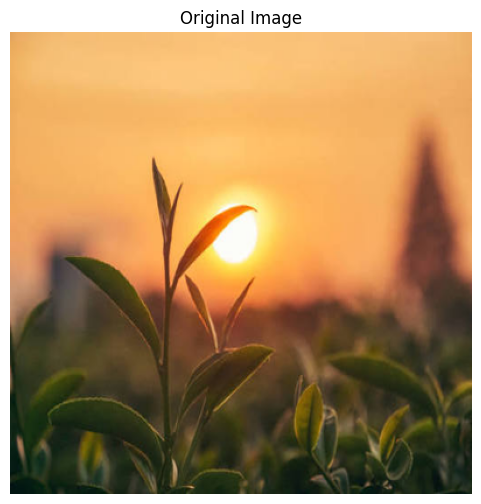

In [5]:
plt.figure(figsize=(6, 6))

plt.imshow(image_array)
plt.axis('off')
plt.title('Original Image')

plt.show()

In [6]:
pixels = image_array.reshape(-1, 3)

print("Pixel data shape:", pixels.shape)

Pixel data shape: (156816, 3)


In [7]:
model = KMeans(
    n_clusters=16,
    random_state=42,
    n_init=10
)

In [8]:
model.fit(pixels)

print("K-Means training completed.")

K-Means training completed.


In [9]:
labels = model.labels_

print("Labels shape:", labels.shape)

Labels shape: (156816,)


In [10]:
colors = model.cluster_centers_

print("Number of colors:", len(colors))
print(colors)

Number of colors: 16
[[ 24.02779244  37.66420405  19.93746702]
 [244.95046235 172.90083664  95.265786  ]
 [104.09388911  85.37070012  17.61432618]
 [ 96.86116643  83.85547653  63.50753912]
 [253.23121387 231.19291908 130.26083815]
 [ 90.0718077   67.88633606  40.007431  ]
 [200.46655305 120.03003835  76.75010652]
 [ 67.71592796  60.26702005  32.55428535]
 [249.67387109 193.44230027 117.92242377]
 [232.97201278 148.97341853  85.51667732]
 [251.7549505  251.04950495 241.89356436]
 [250.01998575 185.81621023 100.45429001]
 [ 47.38621415  50.06445672  25.21560116]
 [228.35690789 103.04111842   8.44407895]
 [121.65584262  69.37153354  44.4464328 ]
 [153.98227503  95.72360732  61.96435528]]


In [11]:
compressed_pixels = colors[labels]

compressed_image = compressed_pixels.reshape(396, 396, 3)

compressed_image = np.clip(
    compressed_image,
    0,
    255
).astype(np.uint8)

print("Compressed image shape:", compressed_image.shape)

Compressed image shape: (396, 396, 3)


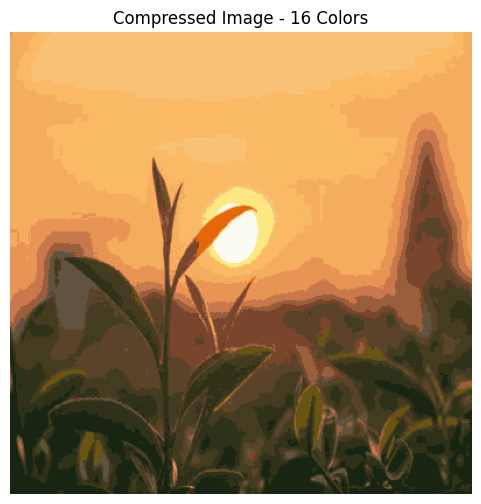

In [12]:
plt.figure(figsize=(6, 6))

plt.imshow(compressed_image)
plt.axis('off')
plt.title('Compressed Image - 16 Colors')

plt.show()

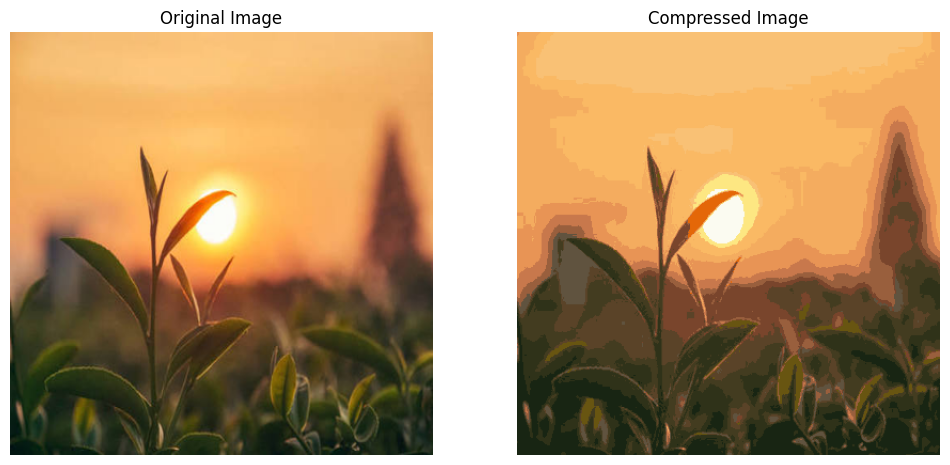

In [13]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(compressed_image)
plt.axis('off')
plt.title('Compressed Image')

plt.show()

In [14]:
compressed_image_pil = Image.fromarray(compressed_image)

compressed_image_pil.save(
    'compressed_image.jpg'
)

print("Compressed image saved successfully.")

Compressed image saved successfully.
